In [1]:
# Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# # Configure data path from mounted Google Drive
# from pathlib import Path

# # Update this path based on your Google Drive folder structure
# # Example: if your dataset is in "My Drive/DEPI Project/Graduation project/tr0ph1c/..."
# # then use: '/content/drive/MyDrive/DEPI Project/Graduation project/tr0ph1c/...'

# source_dir = Path('/content/drive/MyDrive/datasets/')
# source_path = source_dir / 'mitbih_beats1.csv'

# print(f"Dataset path: {source_path}")
# print(f"Path exists: {source_path.exists()}")

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import resample
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.regularizers import l2

In [4]:
# 1. Load Data (source CSV)
from pathlib import Path
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

source_dir = Path('d:/DEPI Project/Graduation project/tr0ph1c/mit-bih-arrhythmia-dataset-lead-ii/versions/2')
source_path = source_dir / 'mitbih_beats1.csv'
# Build a train/test split from the exported dataset without loading it all at once

# Detect whether the CSV includes a header like 'samp_0'..'samp_186','label'
try:
    header_preview = pd.read_csv(source_path, nrows=0)
    header_cols = header_preview.columns.tolist()
except Exception:
    header_cols = []

if header_cols and isinstance(header_cols[0], str) and header_cols[0].startswith('samp_') and 'label' in header_cols:
    # Normal CSV with header
    label_column = 'label'
    feature_columns = [c for c in header_cols if c != label_column]
    read_kwargs = {}
else:
    # CSV has no header (first row is numeric sample values) — read with explicit names
    feature_columns = [f'samp_{i}' for i in range(187)]
    label_column = 'label'
    names = feature_columns + [label_column]
    read_kwargs = {'header': None, 'names': names}

# Read label column to build stratified split
label_frame = pd.read_csv(source_path, usecols=[label_column], **read_kwargs)
if label_frame[label_column].dtype == object:
    label_map = {
    # N class
    'N': 0,
    'L': 0,
    'R': 0,
    'e': 0,
    'j': 0,

    # S class
    'A': 1,
    'a': 1,
    'J': 1,
    'S': 1,

    # V class
    'V': 2,
    'E': 2,

    # F class
    'F': 3,

    # Q class
    '/': 4,
    'f': 4,
    'Q': 4,
    '?': 4
}
    label_values = label_frame[label_column].map(label_map)

    if label_values.isnull().any():
       bad_labels = label_frame[label_column][label_values.isnull()].unique()
       print("Unmapped labels found:", bad_labels)
       raise ValueError("Found unmapped labels in source CSV")
else:
    label_map = None
    label_values = label_frame[label_column].astype(int).to_numpy()

indices = np.arange(len(label_values))
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=label_values,
    random_state=42
 )

train_idx_set = set(train_idx.tolist())
test_idx_set = set(test_idx.tolist())
train_parts = []
test_parts = []
offset = 0

for chunk in pd.read_csv(source_path, usecols=feature_columns + [label_column], chunksize=5000, **read_kwargs):
    chunk = chunk.reset_index(drop=True)
    row_indices = np.arange(offset, offset + len(chunk))
    train_mask = np.fromiter((row in train_idx_set for row in row_indices), dtype=bool, count=len(chunk))
    test_mask = ~train_mask

    train_chunk = chunk.loc[train_mask].copy()
    test_chunk = chunk.loc[test_mask].copy()

    if label_map is not None:
        train_chunk[label_column] = train_chunk[label_column].map(label_map).astype(int)
        test_chunk[label_column] = test_chunk[label_column].map(label_map).astype(int)
    else:
        train_chunk[label_column] = train_chunk[label_column].astype(int)
        test_chunk[label_column] = test_chunk[label_column].astype(int)

    train_chunk[feature_columns] = train_chunk[feature_columns].astype(np.float32)
    test_chunk[feature_columns] = test_chunk[feature_columns].astype(np.float32)

    train_parts.append(train_chunk)
    test_parts.append(test_chunk)
    offset += len(chunk)

df_train = pd.concat(train_parts, ignore_index=True)
df_test = pd.concat(test_parts, ignore_index=True)

# Use the training split as the notebook's working dataframe for the plotting cells
df = df_train.copy()

df.head()

,samp_0,samp_1,samp_2,samp_3,samp_4,samp_5,samp_6,samp_7,samp_8,samp_9,...,samp_179,samp_180,samp_181,samp_182,samp_183,samp_184,samp_185,samp_186,rr_interval,label
0,0.813118,0.137437,-0.455480,-0.315746,-0.348688,-0.304419,-0.341912,-0.329876,-0.333027,-0.333480,...,-0.365582,-0.382943,-0.364429,-0.394966,-0.439309,-0.555457,-0.440798,0.114782,813.888916,0
1,0.871478,0.470326,-0.318922,-0.452666,-0.404857,-0.375925,-0.391132,-0.379182,-0.401614,-0.400218,...,-0.390384,-0.404587,-0.412373,-0.493775,-0.543120,-0.633588,-0.408299,0.079086,811.111084,0
2,0.896992,0.410149,-0.480997,-0.417923,-0.399088,-0.393902,-0.403013,-0.399363,-0.404673,-0.406774,...,-0.353410,-0.360584,-0.351540,-0.404182,-0.472029,-0.539124,-0.311540,0.291610,791.666687,0
3,0.862703,0.122844,-0.515792,-0.391336,-0.408522,-0.406471,-0.412919,-0.395562,-0.398393,-0.386228,...,-0.339592,-0.347442,-0.337899,-0.375666,-0.455436,-0.534557,-0.319318,0.291685,788.888916,0
4,0.924215,0.358533,-0.476891,-0.353166,-0.388816,-0.360479,-0.385845,-0.369145,-0.391573,-0.385828,...,-0.387917,-0.407114,-0.390799,-0.433661,-0.475662,-0.570626,-0.357006,0.166925,652.777771,1


In [5]:
df.head()

,samp_0,samp_1,samp_2,samp_3,samp_4,samp_5,samp_6,samp_7,samp_8,samp_9,...,samp_179,samp_180,samp_181,samp_182,samp_183,samp_184,samp_185,samp_186,rr_interval,label
0,0.813118,0.137437,-0.455480,-0.315746,-0.348688,-0.304419,-0.341912,-0.329876,-0.333027,-0.333480,...,-0.365582,-0.382943,-0.364429,-0.394966,-0.439309,-0.555457,-0.440798,0.114782,813.888916,0
1,0.871478,0.470326,-0.318922,-0.452666,-0.404857,-0.375925,-0.391132,-0.379182,-0.401614,-0.400218,...,-0.390384,-0.404587,-0.412373,-0.493775,-0.543120,-0.633588,-0.408299,0.079086,811.111084,0
2,0.896992,0.410149,-0.480997,-0.417923,-0.399088,-0.393902,-0.403013,-0.399363,-0.404673,-0.406774,...,-0.353410,-0.360584,-0.351540,-0.404182,-0.472029,-0.539124,-0.311540,0.291610,791.666687,0
3,0.862703,0.122844,-0.515792,-0.391336,-0.408522,-0.406471,-0.412919,-0.395562,-0.398393,-0.386228,...,-0.339592,-0.347442,-0.337899,-0.375666,-0.455436,-0.534557,-0.319318,0.291685,788.888916,0
4,0.924215,0.358533,-0.476891,-0.353166,-0.388816,-0.360479,-0.385845,-0.369145,-0.391573,-0.385828,...,-0.387917,-0.407114,-0.390799,-0.433661,-0.475662,-0.570626,-0.357006,0.166925,652.777771,1


In [6]:
df.shape

(87518, 189)

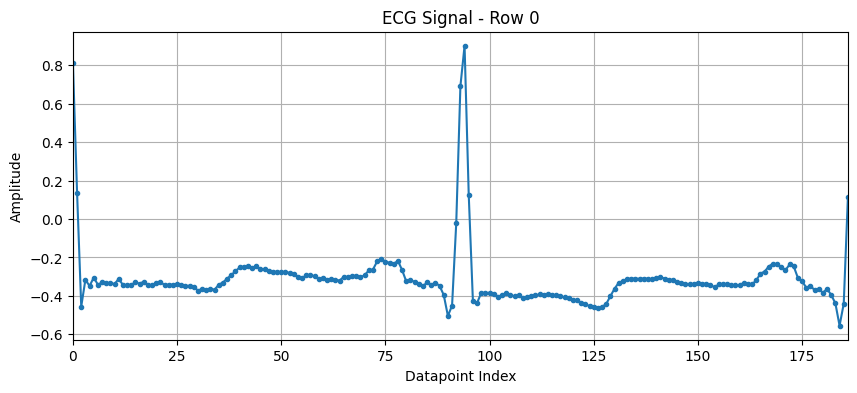

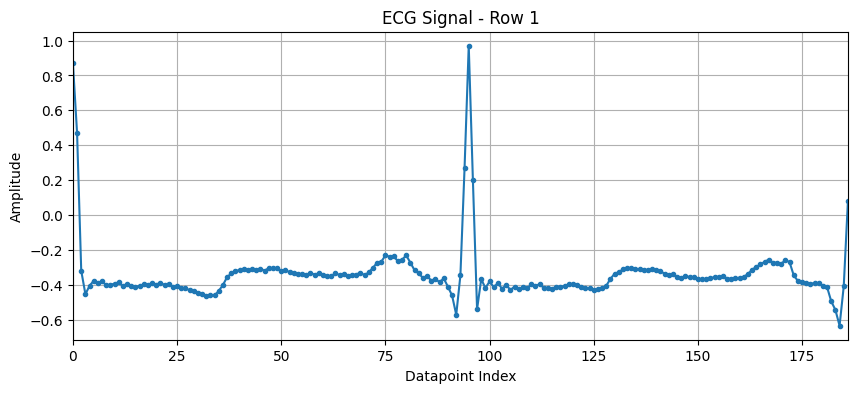

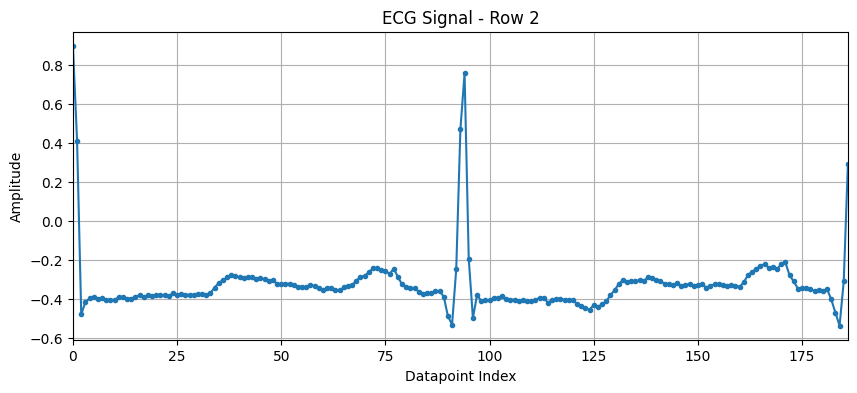

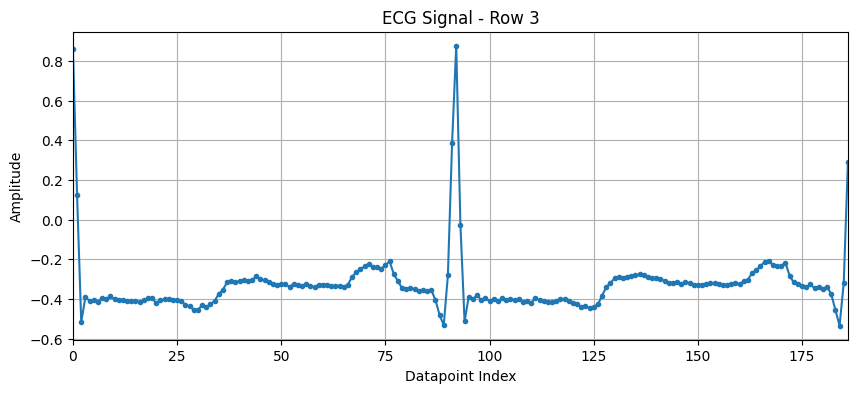

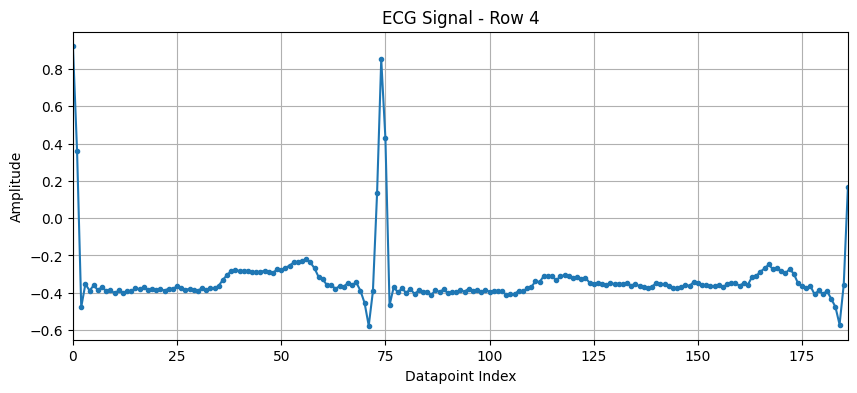

In [7]:
for i in range(5):

    # Only ECG samples
    y = df.iloc[i, :187].values.astype(float)

    x = np.arange(187)

    plt.figure(figsize=(10,4))
    plt.plot(x, y, marker='o', markersize=3)

    plt.xlim(0, 186)
    plt.title(f"ECG Signal - Row {i}")
    plt.xlabel("Datapoint Index")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()


Original Class Distribution:
(87518, 189)
label
0    72438
4     6428
2     5787
1     2223
3      642
Name: count, dtype: int64


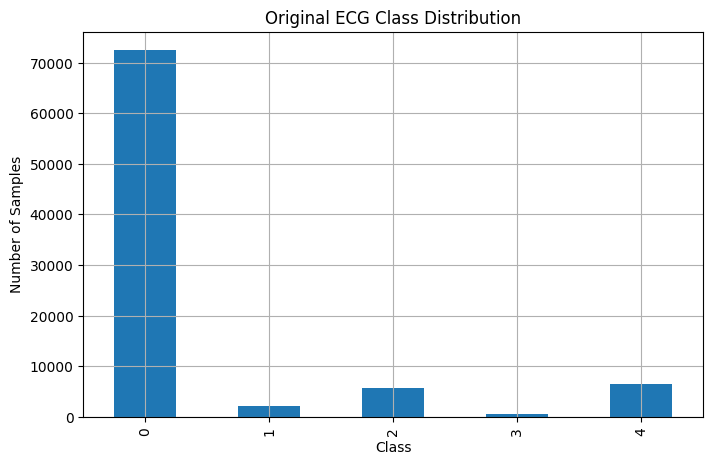

In [8]:
# =========================================================
# 1. ORIGINAL CLASS DISTRIBUTION
# =========================================================

print("\nOriginal Class Distribution:")
print(df.shape)
print(df[label_column].value_counts())


# Visualize imbalance
plt.figure(figsize=(8,5))
df[label_column].value_counts().sort_index().plot(kind='bar')

plt.title("Original ECG Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.grid(True)

plt.show()


In [9]:
# =========================================================
# 2. SEPARATE CLASSES
# =========================================================

df_0 = df[df[label_column] == 0]
df_1 = df[df[label_column] == 1]
df_2 = df[df[label_column] == 2]
df_3 = df[df[label_column] == 3]
df_4 = df[df[label_column] == 4]

print("\nSeparated Shapes:")
print("Class 0:", df_0.shape)
print("Class 1:", df_1.shape)
print("Class 2:", df_2.shape)
print("Class 3:", df_3.shape)
print("Class 4:", df_4.shape)





Separated Shapes:
Class 0: (72438, 189)
Class 1: (2223, 189)
Class 2: (5787, 189)
Class 3: (642, 189)
Class 4: (6428, 189)


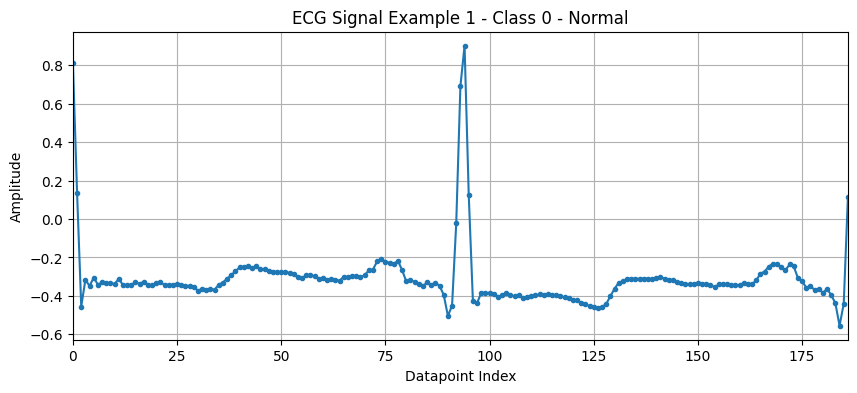

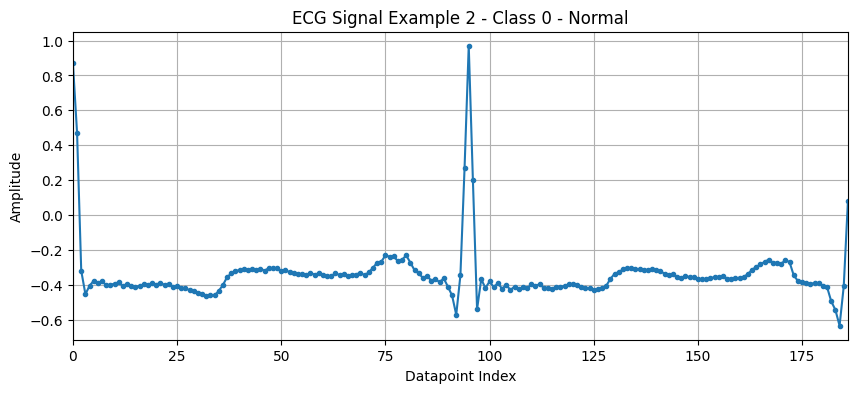

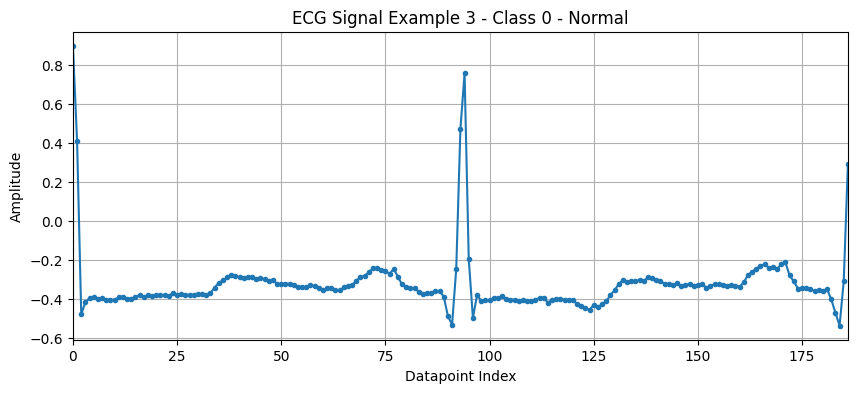

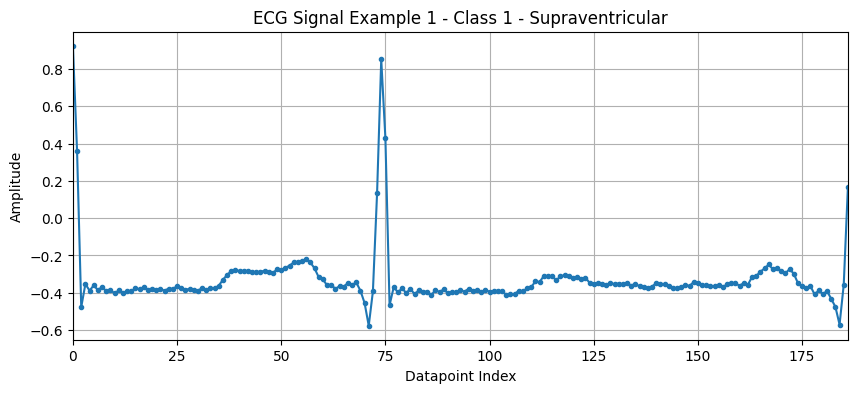

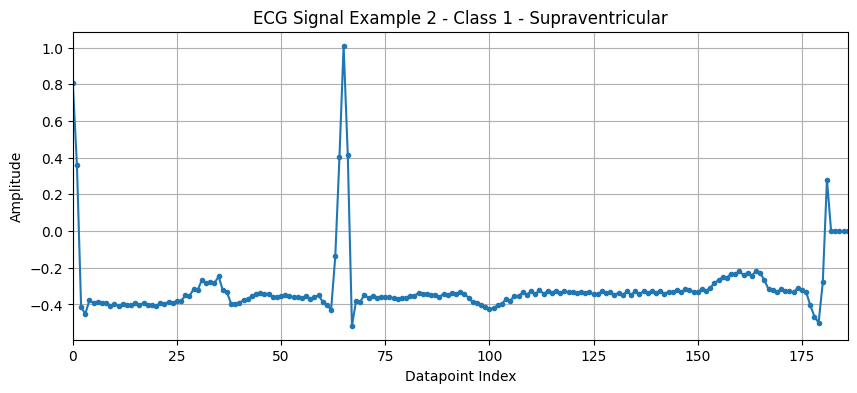

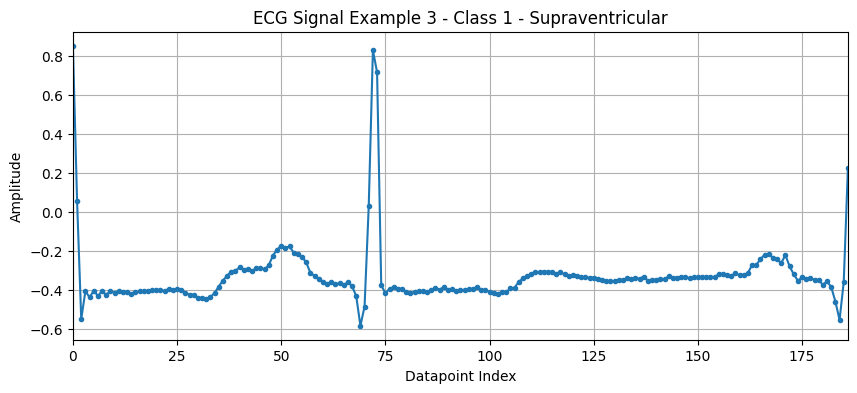

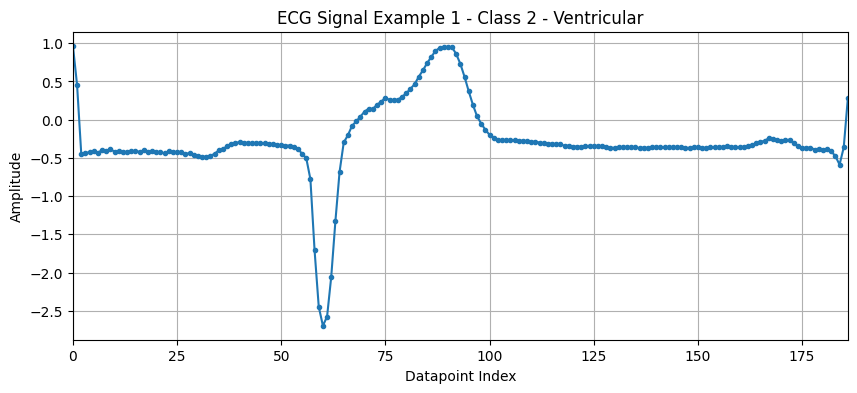

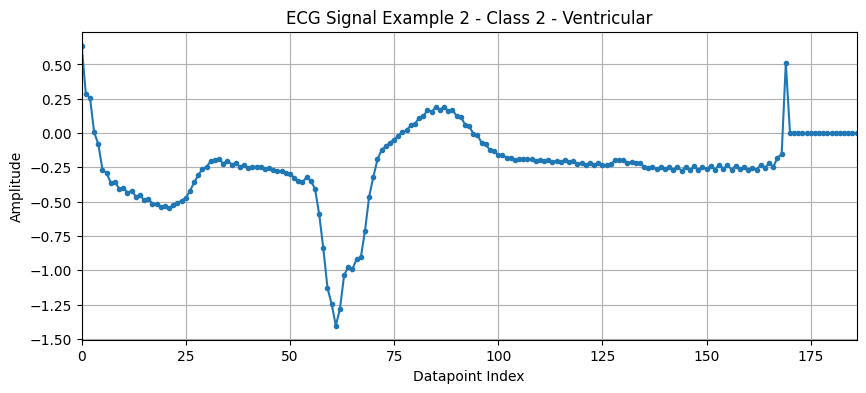

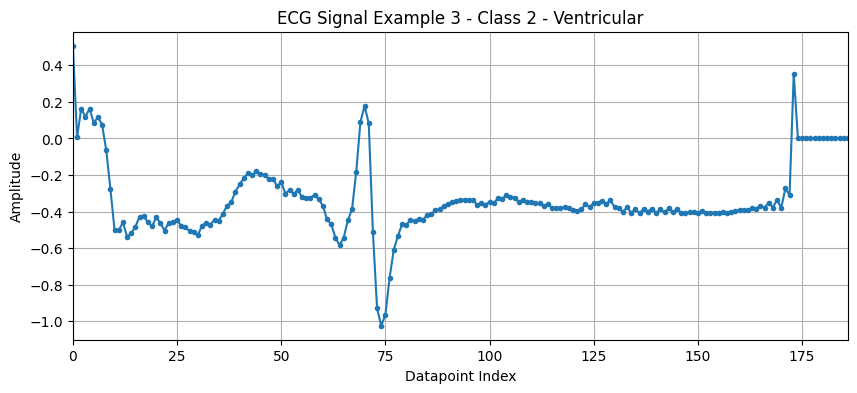

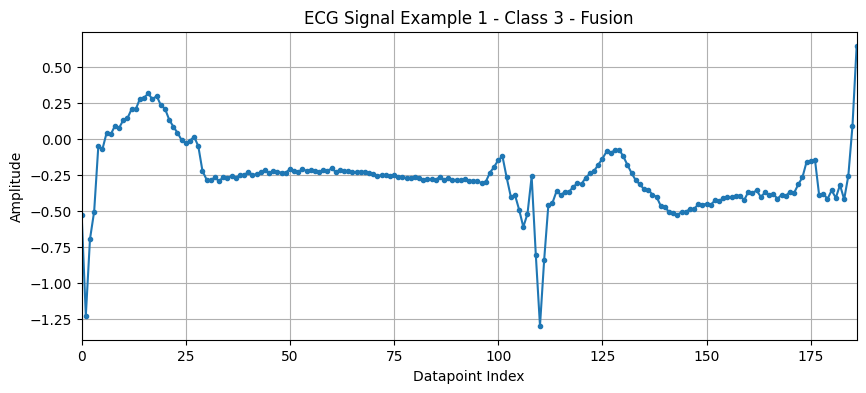

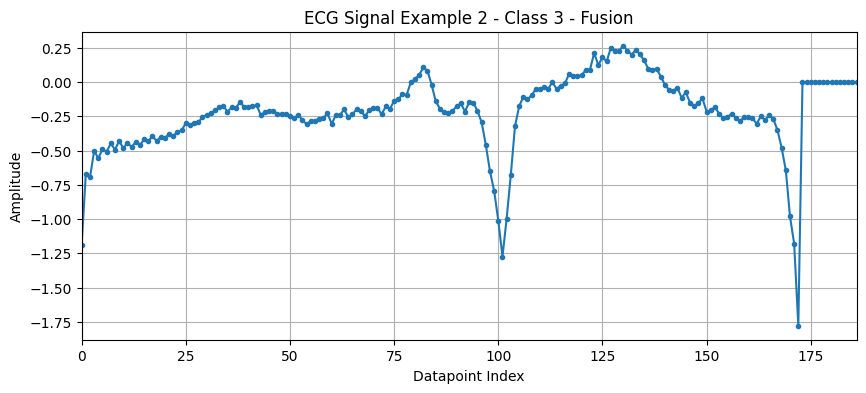

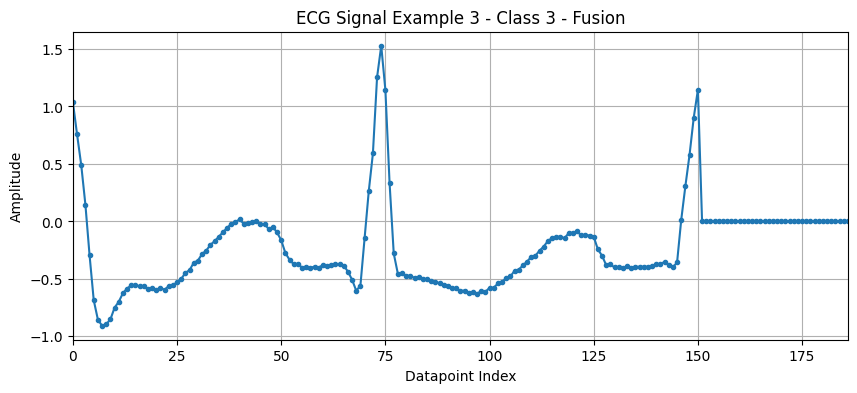

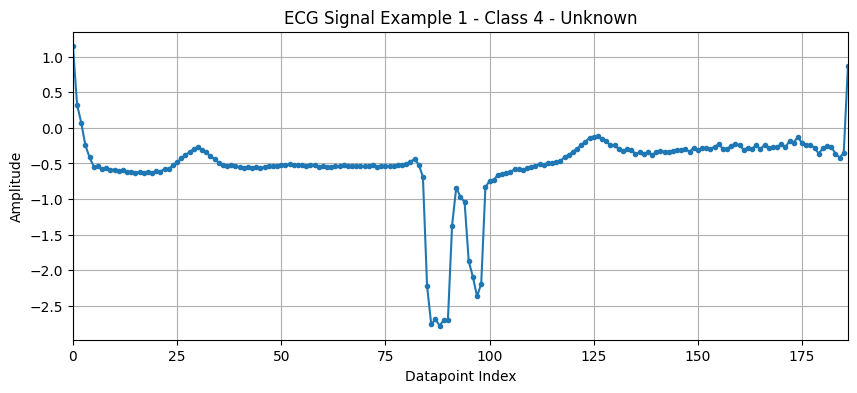

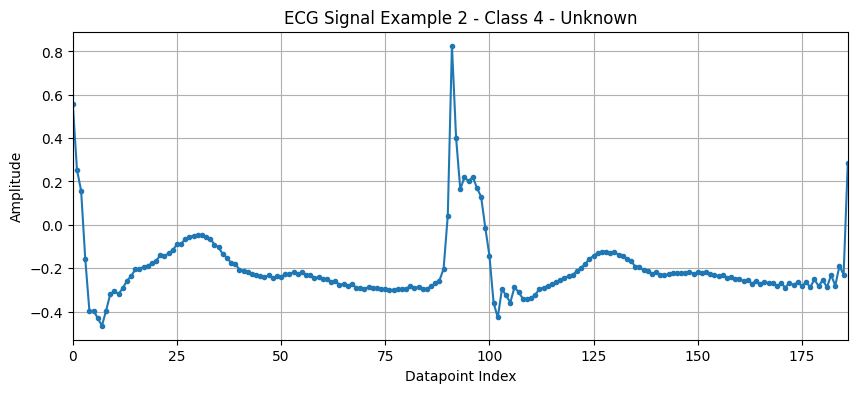

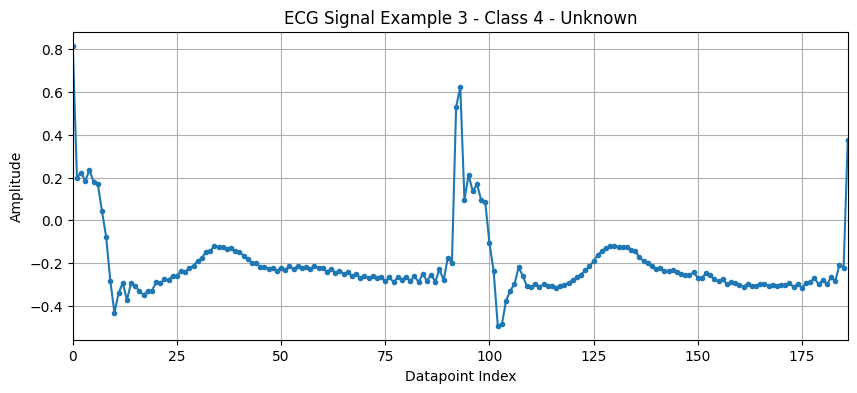

In [10]:
# =========================================================
# 3. VISUALIZE 3 ECG SIGNALS FROM EACH CLASS
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

classes = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
class_dfs = [df.loc[df[label_column] == class_num] for class_num in range(len(classes))]

for class_num, df_class in enumerate(class_dfs):

    if df_class.empty:
        print(f"No samples found for class {class_num}")
        continue

    # Take first 3 samples from this class
    num_samples = min(3, len(df_class))

    for sample_idx in range(num_samples):

        # Get ECG signal only (187 samples)
        y_signal = df_class.iloc[sample_idx, :187].values.astype(float)
        x = np.arange(187)

        plt.figure(figsize=(10, 4))
        plt.plot(x, y_signal, marker='o', markersize=3)

        plt.xlim(0, 186)
        plt.title(
            f"ECG Signal Example {sample_idx+1} - "
            f"Class {class_num} - {classes[class_num]}"
        )
        plt.xlabel("Datapoint Index")
        plt.ylabel("Amplitude")
        plt.grid(True)
        plt.show()

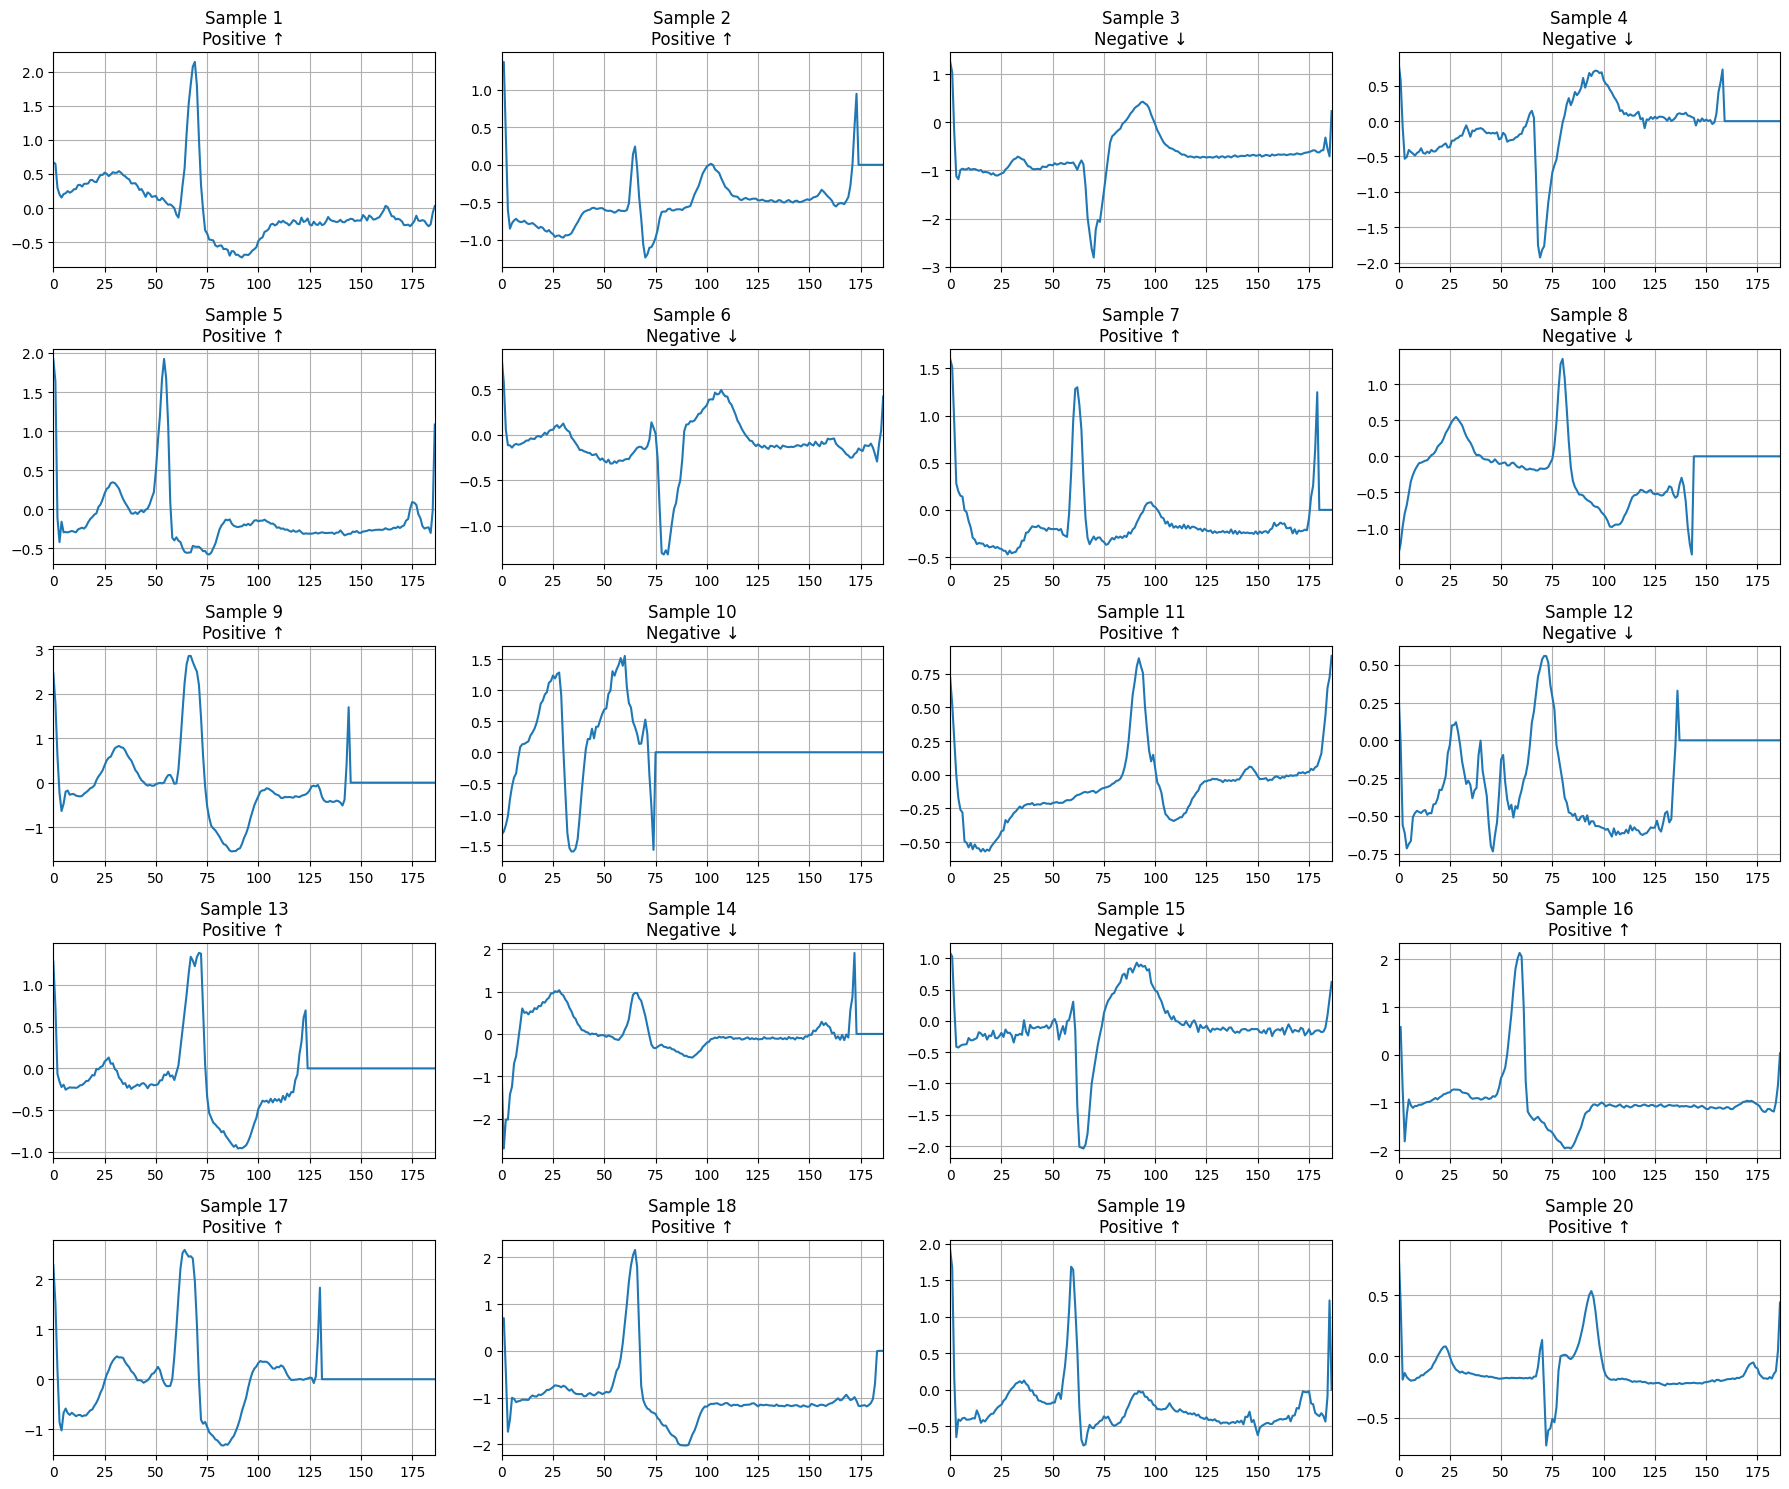

In [11]:
# =========================================================
# RANDOM 20 VENTRICULAR SAMPLES VISUALIZATION
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

# Class 2 = Ventricular
ventricular_df = df[df[label_column] == 2]

if ventricular_df.empty:
    print("No ventricular samples found!")

else:
    # Random 20 samples
    sample_count = min(20, len(ventricular_df))
    random_samples = ventricular_df.sample(n=sample_count, random_state=42)

    # Create 5 rows × 4 columns
    fig, axes = plt.subplots(5, 4, figsize=(18, 15))
    axes = axes.flatten()

    for idx, (_, row) in enumerate(random_samples.iterrows()):

        # ECG signal only
        y_signal = row.iloc[:187].values.astype(float)
        x = np.arange(187)

        # polarity check
        max_val = np.max(y_signal)
        min_val = np.min(y_signal)

        if abs(min_val) > abs(max_val):
            polarity = "Negative ↓"
        else:
            polarity = "Positive ↑"

        axes[idx].plot(x, y_signal)
        axes[idx].set_title(f"Sample {idx+1}\n{polarity}")
        axes[idx].set_xlim(0, 186)
        axes[idx].grid(True)

    plt.tight_layout()
    plt.show()

In [12]:
# =========================================================
# Apply SMOTE
# =========================================================
X = df_train.iloc[:, :187].values

# Convert labels to integer
y = df_train[label_column].astype(int).values
smote = SMOTE(

    sampling_strategy={
        0: 72471,   # Keep majority same
        1: 20000,
        2: 20000,
        3: 20000,
        4: 20000
    },
    random_state=42,
    # Important because class 3 is tiny
    k_neighbors=3
)

X_resampled, y_resampled = smote.fit_resample(X, y)

# =========================================================
# Create Balanced DataFrame
# =========================================================

balanced_df = pd.DataFrame(X_resampled)

balanced_df[187] = y_resampled

# =========================================================
# Shuffle Dataset
# =========================================================

balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)



Balanced Class Distribution:
187
0    72471
4    20000
1    20000
3    20000
2    20000
Name: count, dtype: int64


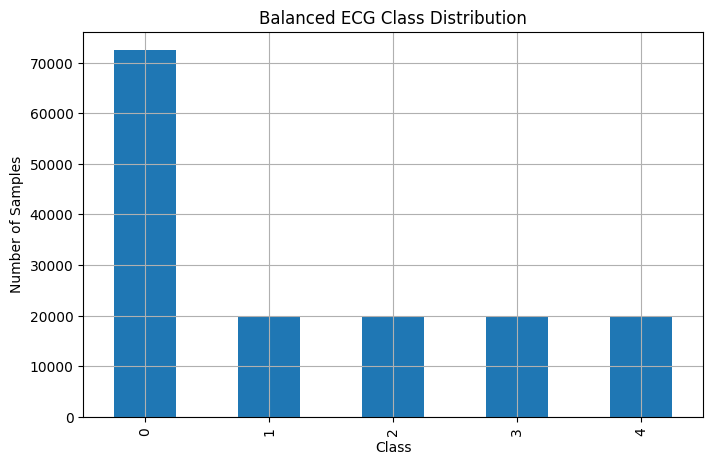

In [13]:
print("\nBalanced Class Distribution:")
print(balanced_df[187].value_counts())
# Visualize balanced dataset
plt.figure(figsize=(8,5))
balanced_df[187].value_counts().sort_index().plot(kind='bar')

plt.title("Balanced ECG Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.grid(True)

plt.show()

In [14]:
# =========================================================
# 5. PREPARE DATA FOR CNN
# =========================================================
X = df_train.iloc[:, :187].values
y = df_train[label_column].values
print("\nBefore Reshape:")
print("X Shape:", X.shape)

# CNN expects: (samples, time_steps, channels)
X = X.reshape(len(X), 187, 1)
print("\nAfter Reshape:")
print("X Shape:", X.shape)

print("\nUnderstanding Shape:")
print("(samples, ECG datapoints, channels)")
print(X.shape)



Before Reshape:
X Shape: (87518, 187)

After Reshape:
X Shape: (87518, 187, 1)

Understanding Shape:
(samples, ECG datapoints, channels)
(87518, 187, 1)


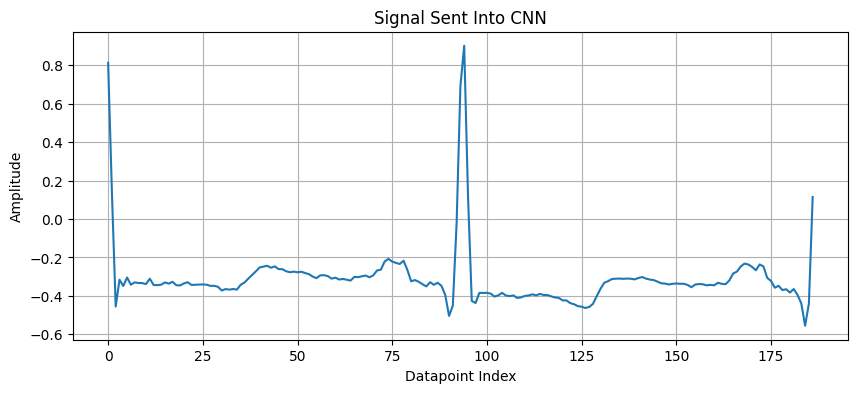

In [15]:
# =========================================================
# 6. VISUALIZE SINGLE INPUT TO CNN
# =========================================================

sample_signal = X[0].reshape(187)

plt.figure(figsize=(10,4))

plt.plot(sample_signal)

plt.title("Signal Sent Into CNN")
plt.xlabel("Datapoint Index")
plt.ylabel("Amplitude")

plt.grid(True)
plt.show()


In [16]:
# =========================================================
# 7. TRAIN TEST
# =========================================================

X_train = X
y_train = y
X_test = df_test.iloc[:, :187].values
y_test = df_test[label_column].astype(int).values

print("\nTrain Test Split:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)



Train Test Split:
X_train: (87518, 187, 1)
X_test : (21880, 187)
y_train: (87518,)
y_test : (21880,)


In [17]:
# =========================================================
# 8. BUILD CNN MODEL
# =========================================================

model = models.Sequential([

    # =====================================================
    # Feature Extraction Block 1
    # =====================================================
    layers.Conv1D(
        filters=64,
        kernel_size=6,
        activation='relu',
        input_shape=(187, 1),
        kernel_regularizer=l2(0.001),
        name='conv1'
    ),

    layers.BatchNormalization(),

    layers.MaxPool1D(
        pool_size=3,
        strides=2
    ),

    # Added Dropout
    layers.Dropout(0.3),

    # =====================================================
    # Feature Extraction Block 2
    # =====================================================
    layers.Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        kernel_regularizer=l2(0.001),
        name='conv2'
    ),

    layers.BatchNormalization(),

    layers.MaxPool1D(
        pool_size=2,
        strides=2
    ),

    # Added Dropout
    layers.Dropout(0.3),

    # =====================================================
    # Convert Feature Maps -> Vector
    # =====================================================
    layers.Flatten(),

    # =====================================================
    # Dense Neural Network
    # =====================================================
    layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=l2(0.001)
    ),

    # Increased Dropout
    layers.Dropout(0.5),

    # =====================================================
    # Output Layer
    # =====================================================
    layers.Dense(
        5,
        activation='softmax'
    )
])

# Show architecture
print("\nCNN Architecture:")
model.summary()

C:\Users\Nader\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



CNN Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv1D)                  │ (None, 182, 64)        │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 182, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 88, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 88, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 44, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 44, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2816)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       180,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,925 (757.52 KB)

 Trainable params: 193,669 (756.52 KB)

 Non-trainable params: 256 (1.00 KB)

In [18]:
# =========================================================
# 9. COMPILE MODEL
# =========================================================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Compiled Successfully")


Model Compiled Successfully


In [19]:
# Noise
def augment_ecg(signal):

    # Copy signal
    augmented = signal.copy()

    # -----------------------------------------------------
    # 1. Gaussian Noise
    # -----------------------------------------------------
    noise = np.random.normal(
        loc=0,
        scale=0.005,
        size=augmented.shape
    )

    augmented = augmented + noise

    # -----------------------------------------------------
    # 2. Random Amplitude Scaling
    # -----------------------------------------------------
    scale = np.random.uniform(0.9, 1.1)

    augmented = augmented * scale

    # -----------------------------------------------------
    # 3. Random Time Shift
    # -----------------------------------------------------
    shift = np.random.randint(-5, 5)

    augmented = np.roll(augmented, shift)

    return augmented

In [20]:
X_augmented = np.array([
    augment_ecg(x.flatten())
    for x in X_train
])
X_augmented = X_augmented.reshape(
    X_augmented.shape[0],
    X_augmented.shape[1],
    1
)

In [21]:
# =========================================================
# 9. TRAIN
# =========================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)
history = model.fit(
    X_augmented,
    y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 79s 109ms/step - accuracy: 0.9264 - loss: 0.4383 - val_accuracy: 0.9296 - val_loss: 0.3666 - learning_rate: 0.0010
Epoch 2/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 76s 112ms/step - accuracy: 0.9576 - loss: 0.2732 - val_accuracy: 0.9744 - val_loss: 0.1947 - learning_rate: 0.0010
Epoch 3/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 81s 118ms/step - accuracy: 0.9658 - loss: 0.2205 - val_accuracy: 0.9811 - val_loss: 0.1590 - learning_rate: 0.0010
Epoch 4/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 87s 127ms/step - accuracy: 0.9688 - loss: 0.1944 - val_accuracy: 0.9833 - val_loss: 0.1450 - learning_rate: 0.0010
Epoch 5/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 78s 114ms/step - accuracy: 0.9724 - loss: 0.1796 - val_accuracy: 0.9818 - val_loss: 0.1431 - learning_rate: 0.0010
Epoch 6/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 72s 99ms/step - accuracy: 0.9718 - loss: 0.1761 - val_accuracy: 0.9835 - val_loss: 0.1421 - learning_rate: 0.0010
Epoch 7/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 64s 94ms/step - accuracy: 0.972

In [22]:
# =========================================================
# 10. TEST ACCURACY
# =========================================================

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

684/684 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9915 - loss: 0.0511

Test Accuracy: 0.9914990663528442
Test Loss: 0.05106321722269058


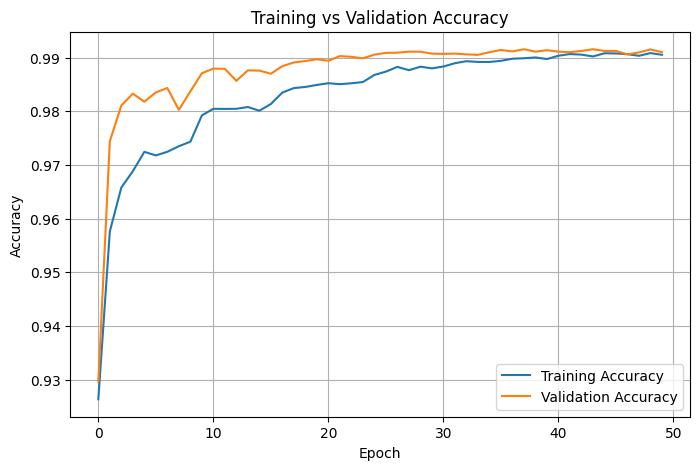

In [23]:
# =========================================================
# 11. VISUALIZE OVERFITTING
# =========================================================

# Training vs Validation Accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()


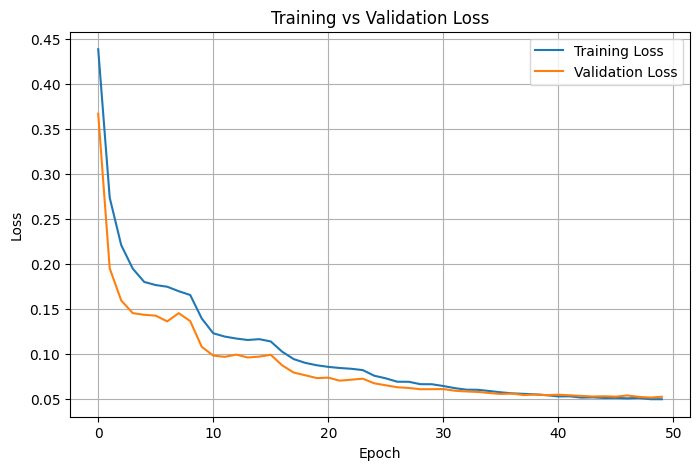

In [24]:
# Training vs Validation Loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

684/684 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step

CLASSIFICATION REPORT

                  precision    recall  f1-score   support

          Normal     0.9933    0.9983    0.9958     18110
Supraventricular     0.9509    0.8705    0.9089       556
     Ventricular     0.9818    0.9696    0.9757      1447
          Fusion     0.9259    0.7812    0.8475       160
         Unknown     0.9981    0.9969    0.9975      1607

        accuracy                         0.9915     21880
       macro avg     0.9700    0.9233    0.9451     21880
    weighted avg     0.9913    0.9915    0.9913     21880


CONFUSION MATRIX

[[18080    19     6     2     3]
 [   66   484     6     0     0]
 [   31     5  1403     8     0]
 [   21     1    13   125     0]
 [    4     0     1     0  1602]]


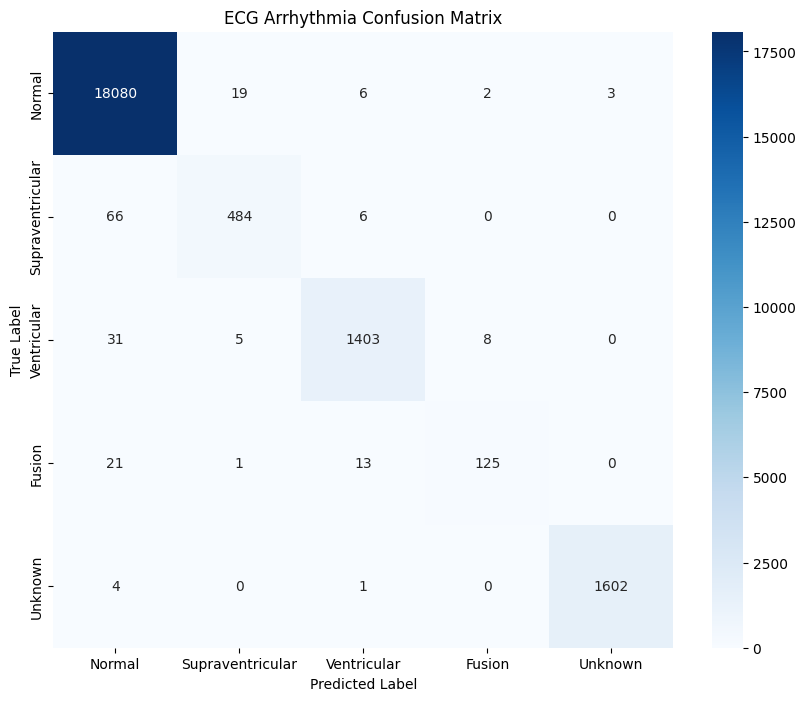

In [25]:


# =========================================================
# PREDICTIONS
# =========================================================

# Predict probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities -> class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = y_test

# If one-hot encoded use:
# y_true = np.argmax(y_test, axis=1)

# =========================================================
# CLASS NAMES
# =========================================================

class_names = [
    'Normal',
    'Supraventricular',
    'Ventricular',
    'Fusion',
    'Unknown'
]

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print("\n=================================================")
print("CLASSIFICATION REPORT")
print("=================================================\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_true, y_pred)

print("\n=================================================")
print("CONFUSION MATRIX")
print("=================================================\n")

print(cm)

# =========================================================
# PLOT CONFUSION MATRIX
# =========================================================

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("ECG Arrhythmia Confusion Matrix")

plt.show()

In [26]:
# from pathlib import Path
# from google.colab import files

model_path = Path('/content/ecg_cnn_model.keras')

if model_path.exists():
    print(f'Found model file: {model_path}')
    files.download(str(model_path))
else:
    print(f'File not found: {model_path}')
    print('Run the save cell first, or check the filename.')

File not found: \content\ecg_cnn_model.keras
Run the save cell first, or check the filename.


In [27]:
# =========================================================
# 11. SAVE MODEL TO GOOGLE DRIVE
# =========================================================
# model.save("ecg_model_new.keras")
from pathlib import Path

save_dir = Path('/content/drive/MyDrive/models')
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / 'ecg_model_resaved.keras'

model.save(save_path)

print(f"\nModel saved to Google Drive: {save_path}")


Model saved to Google Drive: \content\drive\MyDrive\models\ecg_model_resaved.keras


In [31]:
# =========================================================
# 11. SAVE MODEL TO GOOGLE DRIVE
# =========================================================
model.save("ecg_cnn_model.keras")
from pathlib import Path

save_dir = Path('/')
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / 'ecg_model_new.keras'

model.save(save_path)

print(f"\nModel saved to Google Drive: {save_path}")


Model saved to Google Drive: \ecg_model_new.keras


In [29]:
# =========================================================
# 12. EXPORT INFERENCE MODULE + WEIGHTS
# =========================================================
from pathlib import Path
import textwrap

save_dir = Path('/content/drive/MyDrive/models')
save_dir.mkdir(parents=True, exist_ok=True)

weights_path = save_dir / 'ecg_model_last.weights.h5'
model.save_weights(weights_path)
print(f"Weights saved: {weights_path}")

inference_path = save_dir / 'ecg_inference.py'
module_code = textwrap.dedent("""
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2

def build_model(input_shape=(187, 1), num_classes=5):
    model = models.Sequential([
        layers.Conv1D(
            filters=64,
            kernel_size=6,
            activation='relu',
            input_shape=input_shape,
            kernel_regularizer=l2(0.001),
            name='conv1'
        ),
        layers.BatchNormalization(),
        layers.MaxPool1D(pool_size=3, strides=2),
        layers.Dropout(0.3),
        layers.Conv1D(
            filters=64,
            kernel_size=3,
            activation='relu',
            kernel_regularizer=l2(0.001),
            name='conv2'
        ),
        layers.BatchNormalization(),
        layers.MaxPool1D(pool_size=2, strides=2),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def preprocess(features):
    x = np.asarray(features, dtype=np.float32)
    if x.shape == (187,):
        x = x.reshape(1, 187, 1)
    elif x.shape == (1, 187):
        x = x.reshape(1, 187, 1)
    elif x.shape == (187, 1):
        x = x.reshape(1, 187, 1)
    elif x.ndim == 2 and x.shape[1] == 187:
        x = x[..., None]
    elif x.ndim == 3 and x.shape[1:] == (187, 1):
        pass
    else:
        raise ValueError("Expected 187-sample ECG signal(s).")
    return x

class model:
    def __init__(self):
        self.model = build_model()

    def load(self, weights_path):
        self.model.load_weights(weights_path)
        return self

    def classify(self, features):
        x = preprocess(features)
        probs = self.model.predict(x, verbose=0)
        labels = np.argmax(probs, axis=1)
        confidences = np.max(probs, axis=1)
        return labels, confidences

    def predict(self, features):
        x = preprocess(features)
        return self.model.predict(x, verbose=0)
""").lstrip()

inference_path.write_text(module_code, encoding="utf-8")
print(f"Inference module saved: {inference_path}")

Weights saved: \content\drive\MyDrive\models\ecg_model_last.weights.h5
Inference module saved: \content\drive\MyDrive\models\ecg_inference.py


In [30]:
# =========================================================
# 13. DOWNLOAD WEIGHTS + MODULE
# =========================================================
from pathlib import Path
from google.colab import files

save_dir = Path('/content/drive/MyDrive/models')
weights_path = save_dir / 'ecg_model_last.weights.h5'
inference_path = save_dir / 'ecg_inference.py'

if Path('/content/ecg_model_resaved.keras').exists():
    files.download('/content/ecg_model_resaved.keras')  
else:
    print("fuck")

if weights_path.exists():
    print(f'Found weights: {weights_path}')
    files.download(str(weights_path))
else:
    print(f'Weights not found: {weights_path}')
    print('Run the export cell first.')

if inference_path.exists():
    print(f'Found module: {inference_path}')
    files.download(str(inference_path))
else:
    print(f'Module not found: {inference_path}')
    print('Run the export cell first.')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
import json
import numpy as np
import tensorflow as tf
from confluent_kafka import Consumer, KafkaError
import datetime

# 1. Verify Model is Loaded
if 'model' not in globals():
    print("Model instance not found in notebook memory. Loading 'ecg_model.keras'...")
    model = tf.keras.models.load_model("ecg_model.keras")
else:
    print("Successfully hooked into active notebook model.")

# AAMI 5 Class mapping
CLASS_MAPPING = {0: 'N', 1: 'S', 2: 'V', 3: 'F', 4: 'Q'}

# ==========================================
# Database Simulation Function
# ==========================================
def save_prediction_to_db(user_id, session_id, timestamp, predicted_class, confidence):
    """
    Mock function to simulate saving the prediction to a database (e.g., PostgreSQL, MongoDB).
    In a real system, you would insert this record into your database here.
    """
    # Example SQL insertion logic (Conceptual)
    # query = \"\"\"
    #     INSERT INTO ecg_predictions (user_id, session_id, timestamp, prediction, confidence)
    #     VALUES (%s, %s, %s, %s, %s)
    # \"\"\"
    # cursor.execute(query, (user_id, session_id, timestamp, predicted_class, confidence))
    # db.commit()
    
    # For this notebook, we just print the "save" action
    print(f"[DB SAVE] User: {user_id} | Session: {session_id} | Time: {timestamp} | Class: {predicted_class} | Conf: {confidence:.4f}")


# 2. Configure Kafka Consumer
conf = {
    'bootstrap.servers': 'localhost:9092',    # Replace with your Kafka broker address
    'group.id': 'ecg-multi-user-inference',
    'auto.offset.reset': 'latest',
    'enable.auto.commit': True
}

KAFKA_TOPIC = 'ecg-preprocessed-beats'        # Replace with your topic name
consumer = Consumer(conf)
consumer.subscribe([KAFKA_TOPIC])

print(f"🚀 Real-time inference engine running. Listening to topic: '{KAFKA_TOPIC}'...")
print("Serving multiple patients concurrently with database tracking. Press 'Stop' to exit.\\n")

# 3. Dynamic Micro-Batching Loop
BATCH_SIZE = 32
POLL_TIMEOUT = 0.1

try:
    while True:
        messages = consumer.consume(num_messages=BATCH_SIZE, timeout=POLL_TIMEOUT)
        
        if not messages:
            continue
            
        batch_signals = []
        batch_metadata = [] # Store all tracing data together
        
        for msg in messages:
            if msg.error():
                if msg.error().code() != KafkaError._PARTITION_EOF:
                    print(f"Kafka Error: {msg.error()}")
                continue
                
            # Expected JSON format: 
            # {"user_id": "patient_1", "session_id": "sess_A", "timestamp": "2026-05-28T...", "signal": [187 floats]}
            try:
                payload = json.loads(msg.value().decode('utf-8'))
                
                # Extract Tracing Metadata
                user_id = payload.get('user_id', 'unknown_user')
                session_id = payload.get('session_id', 'unknown_session')
                timestamp = payload.get('timestamp', datetime.datetime.now().isoformat())
                
                signal = payload.get('signal', [])
                
                if len(signal) == 187:
                    batch_signals.append(signal)
                    # Bind the metadata to the signal index
                    batch_metadata.append({
                        "user_id": user_id,
                        "session_id": session_id,
                        "timestamp": timestamp
                    })
                else:
                    print(f"⚠️ Dropping frame: User {user_id} sent incorrect dimensions ({len(signal)} samples).")
            except Exception as e:
                print(f"Failed to parse incoming message payload: {e}")
                
        # Execute Inference
        # if batch_signals:
        #     X_batch = np.array(batch_signals, dtype=np.float32)
        #     X_batch = np.expand_dims(X_batch, axis=-1)
            
        #     predictions = model.predict(X_batch, verbose=0)
            
        #     pred_classes = np.argmax(predictions, axis=1)
        #     confidences = np.max(predictions, axis=1)
            
        #     # Map predictions back to metadata and save
        #     for i in range(len(batch_metadata)):
        #         meta = batch_metadata[i]
        #         label = CLASS_MAPPING.get(pred_classes[i], 'Unknown')
        #         score = float(confidences[i]) # Convert to standard float for DB insertion
                
        #         # Call the database saving function
        #         save_prediction_to_db(
        #             user_id=meta['user_id'],
        #             session_id=meta['session_id'],
        #             timestamp=meta['timestamp'],
        #             predicted_class=label,
        #             confidence=score
        #         )
        # ... inside the while loop ...
        if batch_signals:
            try:
                X_batch = np.array(batch_signals, dtype=np.float32)
                X_batch = np.expand_dims(X_batch, axis=-1)
                
                # Inference
                predictions = model.predict(X_batch, verbose=0)
                pred_classes = np.argmax(predictions, axis=1)
                confidences = np.max(predictions, axis=1)
                
                # Save results asynchronously
                for i in range(len(batch_metadata)):
                    meta = batch_metadata[i]
                    # Submit to the thread pool to avoid blocking
                    db_executor.submit(
                        save_prediction_to_db,
                        user_id=meta['user_id'],
                        session_id=meta['session_id'],
                        timestamp=meta['timestamp'],
                        predicted_class=CLASS_MAPPING.get(pred_classes[i], 'Unknown'),
                        confidence=float(confidences[i])
                    )
            except Exception as e:
                print(f"❌ Inference Error: {e}")

except KeyboardInterrupt:
    print("\\n🛑 Inference loop terminated gracefully.")
# Place this at the very end of your script
finally:
    print("Closing Kafka consumer...")
    consumer.close()
    print("Shutting down database worker pool...")
    db_executor.shutdown(wait=True)

ModuleNotFoundError: No module named 'confluent_kafka'

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "content/drive/MyDrive/ecg_model_new.keras"
)

print(model.input_shape)
print(model.output_shape)

ValueError: File not found: filepath=content/drive/MyDrive/ecg_model_new.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/models/ecg_model_new.keras",
    compile=False,
    safe_mode=False
)

model.save(
    "ecg_model_resaved.keras"
)

print("DONE")

DONE


In [ ]:
%pip show tensorflow

Name: tensorflow
Version: 2.20.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing_extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tf_keras, ydf_tf


In [ ]:
import keras
import tensorflow as tf

print("TF:", tf.__version__)
print("Keras:", keras.__version__)

TF: 2.20.0
Keras: 3.13.2


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/models/ecg_model_new.keras",
    compile=False,
    safe_mode=False
)

print("LOADED")
print(model.input_shape)
print(model.output_shape)

LOADED
(None, 187, 1)
(None, 5)


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "ecg_model.keras",
    compile=False
)

ValueError: File not found: filepath=ecg_model.keras. Please ensure the file is an accessible `.keras` zip file.